# 07/05/25

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

visa_df=pd.read_csv('Visadataset.csv')
cat=visa_df.select_dtypes(include='object').columns
num=visa_df.select_dtypes(exclude='object').columns
num

Index(['no_of_employees', 'yr_of_estab', 'prevailing_wage'], dtype='object')

- we have two scale methods

    - 1. Z-score

    - 2. MinMaxScore

<img class="XqHOTb IGEbUc" alt="Z = \frac{x - \mu}{\sigma}" src="https://www.gstatic.com/education/formulas2/553212783/en/z_score.svg" role="img" data-csiid="jk0baJ6uFrTgseMPybir8Qo_14" data-atf="0">

In [ ]:
# Step-1: x= prevailing wage data
# Step-2: Calculate mean: u
# Step-3: Calculate std: sigma
# Step-4: Nr= Step1-Step2
# Step-5: Z= Step4/Step3
# Step-6: Create a new column pwage_z
# Step-7: Draw the distribution plot for both prevailing_wage and pwage_z

# Observation: Even though values are modified data distribution kids

In [12]:
wage_data=visa_df['prevailing_wage']  # reading the column
wage_mean=round(np.mean(wage_data),2)
u=wage_mean

In [14]:
x=visa_df['prevailing_wage']
u=x.mean()
sd=x.std()
Nr=x-u
visa_df['p_wage_z']=Nr/sd

In [16]:
visa_df[['prevailing_wage','p_wage_z']]

,prevailing_wage,p_wage_z
0,592.2029,-1.398510
1,83425.6500,0.169832
2,122996.8600,0.919060
3,83434.0300,0.169991
4,149907.3900,1.428576
...,...,...
25475,77092.5700,0.049923
25476,279174.7900,3.876083
25477,146298.8500,1.360253
25478,86154.7700,0.221504


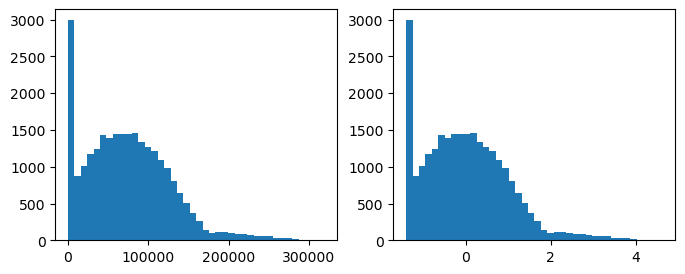

In [18]:
plt.figure(figsize=(8,3))
plt.subplot(1,2,1).hist(visa_df['prevailing_wage'],bins=40)
plt.subplot(1,2,2).hist(visa_df['p_wage_z'],bins=40)
plt.show()

**Standard Scaler**

  - sklearn

      - preprocessing

          - standardscaler

In [ ]:
# Read the package
# Save the package
# Apply fit transform

In [20]:
visa_df=pd.read_csv('Visadataset.csv')
cat=visa_df.select_dtypes(include='object').columns
num=visa_df.select_dtypes(exclude='object').columns
num

Index(['no_of_employees', 'yr_of_estab', 'prevailing_wage'], dtype='object')

In [58]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
visa_df['p_wage_ss']=ss.fit_transform(visa_df[['prevailing_wage']])

In [60]:
visa_df[['prevailing_wage','p_wage_z','p_wage_ss']]

,prevailing_wage,p_wage_z,p_wage_ss
0,592.2029,-1.398537,-1.398537
1,83425.6500,0.169835,0.169835
2,122996.8600,0.919079,0.919079
3,83434.0300,0.169994,0.169994
4,149907.3900,1.428604,1.428604
...,...,...,...
25475,77092.5700,0.049924,0.049924
25476,279174.7900,3.876159,3.876159
25477,146298.8500,1.360280,1.360280
25478,86154.7700,0.221509,0.221509


**Normalization**

<img src="https://miro.medium.com/v2/resize:fit:888/1*ye1I00S61GqpR34ABZZFLQ.png" jsaction="" class="sFlh5c FyHeAf iPVvYb" style="max-width: 444px; height: 107px; margin: 10px 0px; width: 305px;" alt="How Min-Max Scaler Works. The math behind the min-max scaler | by Kamlesh  Kumar Rangi | Medium" jsname="kn3ccd">

In [22]:
visa_df=pd.read_csv('Visadataset.csv')

In [ ]:
# Step-1: Read the prevailing wage data X
# Step-2: Calculate X_min
# Step-3: Calculate X_max
# Step-4: Nr= X-X_min
# Step-5: Dr= X_max-X_min
# Step-6: wage_norm=Nr/Dr
# Check the max(1) and min(0) values

# Sklearn
# preprocessing
# MinMaxScaler

In [76]:
X=visa_df['prevailing_wage']
X_min=X.min()
X_max=X.max()
Nr=X-X_min
Dr= X_max-X_min
Nr/Dr
visa_df['p_wage_norm']=Nr/Dr

In [24]:
Nr=visa_df['prevailing_wage']-visa_df['prevailing_wage'].min()
Dr=visa_df['prevailing_wage'].max()-visa_df['prevailing_wage'].min()
visa_df['p_wage_norm']=Nr/Dr

In [26]:
# idx max will give an ID where each column has maximum
visa_df[['prevailing_wage','p_wage_norm']].idxmax()

prevailing_wage    21077
p_wage_norm        21077
dtype: int64

In [80]:
# idx min will give an ID where each column has minimum
visa_df[['prevailing_wage','p_wage_norm']].idxmin()

prevailing_wage    20575
p_wage_norm        20575
dtype: int64

In [30]:
visa_df.iloc[[21077,20575]]

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,p_wage_norm
21077,EZYV21078,Asia,High School,N,N,442,2006,Midwest,319210.2700,Year,Y,Denied,1.0
20575,EZYV20576,North America,Master's,N,N,1552,2004,Northeast,2.1367,Hour,Y,Certified,0.0


In [32]:
from sklearn.preprocessing import MinMaxScaler
mms=MinMaxScaler()
mms.fit_transform(visa_df[['prevailing_wage']])

array([[0.00184853],
       [0.2613452 ],
       [0.385312  ],
       ...,
       [0.45831136],
       [0.26989486],
       [0.22203311]])